In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


Loading The DATASET

In [137]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arunjangir245/boston-housing-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\rumal\.cache\kagglehub\datasets\arunjangir245\boston-housing-dataset\versions\2


In [3]:
from google.colab import drive
drive.mount('/content/drive')



ModuleNotFoundError: No module named 'google'

 :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pupil-teacher ratio by town
        - B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
        - LSTAT    % lower status of the population
        - MEDV     Median value of owner-occupied homes in $1000's

    :Missing Attribute Values: None

In [138]:
import pandas as pd
boston_df = pd.read_csv('C:\\6 SEM\\ML PROJECTS\\House Prediction\\House-Prediction-Project-Linear-Regression\\HousingData.csv')

In [139]:
boston_df.keys() # returns the column names

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='str')

In [140]:
## Description of the dataset
boston_df.info()        # column types and null counts
boston_df.describe()    # statistical summary
boston_df.head()        # first 5 rows

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


Preparation of the Dataset


In [147]:
y = boston_df[['Price']]  # Target variable (house prices)


In [8]:
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [146]:
boston_df.rename(columns={'MEDV': 'Price'}, inplace=True)

In [148]:
boston_df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [149]:
boston_df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [150]:
#Checking Miissing Values
boston_df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
Price       0
dtype: int64

**EDA**

In [151]:
boston_df.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
CRIM,1.000000,-0.191178,0.401863,-0.054355,0.417130,-0.219150,0.354342,-0.374166,0.624765,0.580595,0.281110,-0.381411,0.444943,-0.391363
ZN,-0.191178,1.000000,-0.531871,-0.037229,-0.513704,0.320800,-0.563801,0.656739,-0.310919,-0.312371,-0.414046,0.171303,-0.414193,0.373136
INDUS,0.401863,-0.531871,1.000000,0.059859,0.764866,-0.390234,0.638431,-0.711709,0.604533,0.731055,0.390954,-0.360532,0.590690,-0.481772
CHAS,-0.054355,-0.037229,0.059859,1.000000,0.075097,0.104885,0.078831,-0.093971,0.001468,-0.032304,-0.111304,0.051264,-0.047424,0.181391
NOX,0.417130,-0.513704,0.764866,0.075097,1.000000,-0.302188,0.731548,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.582641,-0.427321
RM,-0.219150,0.320800,-0.390234,0.104885,-0.302188,1.000000,-0.247337,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.614339,0.695360
AGE,0.354342,-0.563801,0.638431,0.078831,0.731548,-0.247337,1.000000,-0.744844,0.458349,0.509114,0.269226,-0.275303,0.602891,-0.394656
DIS,-0.374166,0.656739,-0.711709,-0.093971,-0.769230,0.205246,-0.744844,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.493328,0.249929
RAD,0.624765,-0.310919,0.604533,0.001468,0.611441,-0.209847,0.458349,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.479541,-0.381626
TAX,0.580595,-0.312371,0.731055,-0.032304,0.668023,-0.292048,0.509114,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.536110,-0.468536


Multicollinearity is a statistical phenomenon in multiple regression where two or more independent variables are highly correlated with each other.undermines the statistical reliability of the model by inflating the standard errors of the regression coefficients, making it difficult to isolate the individual effect of each predictor

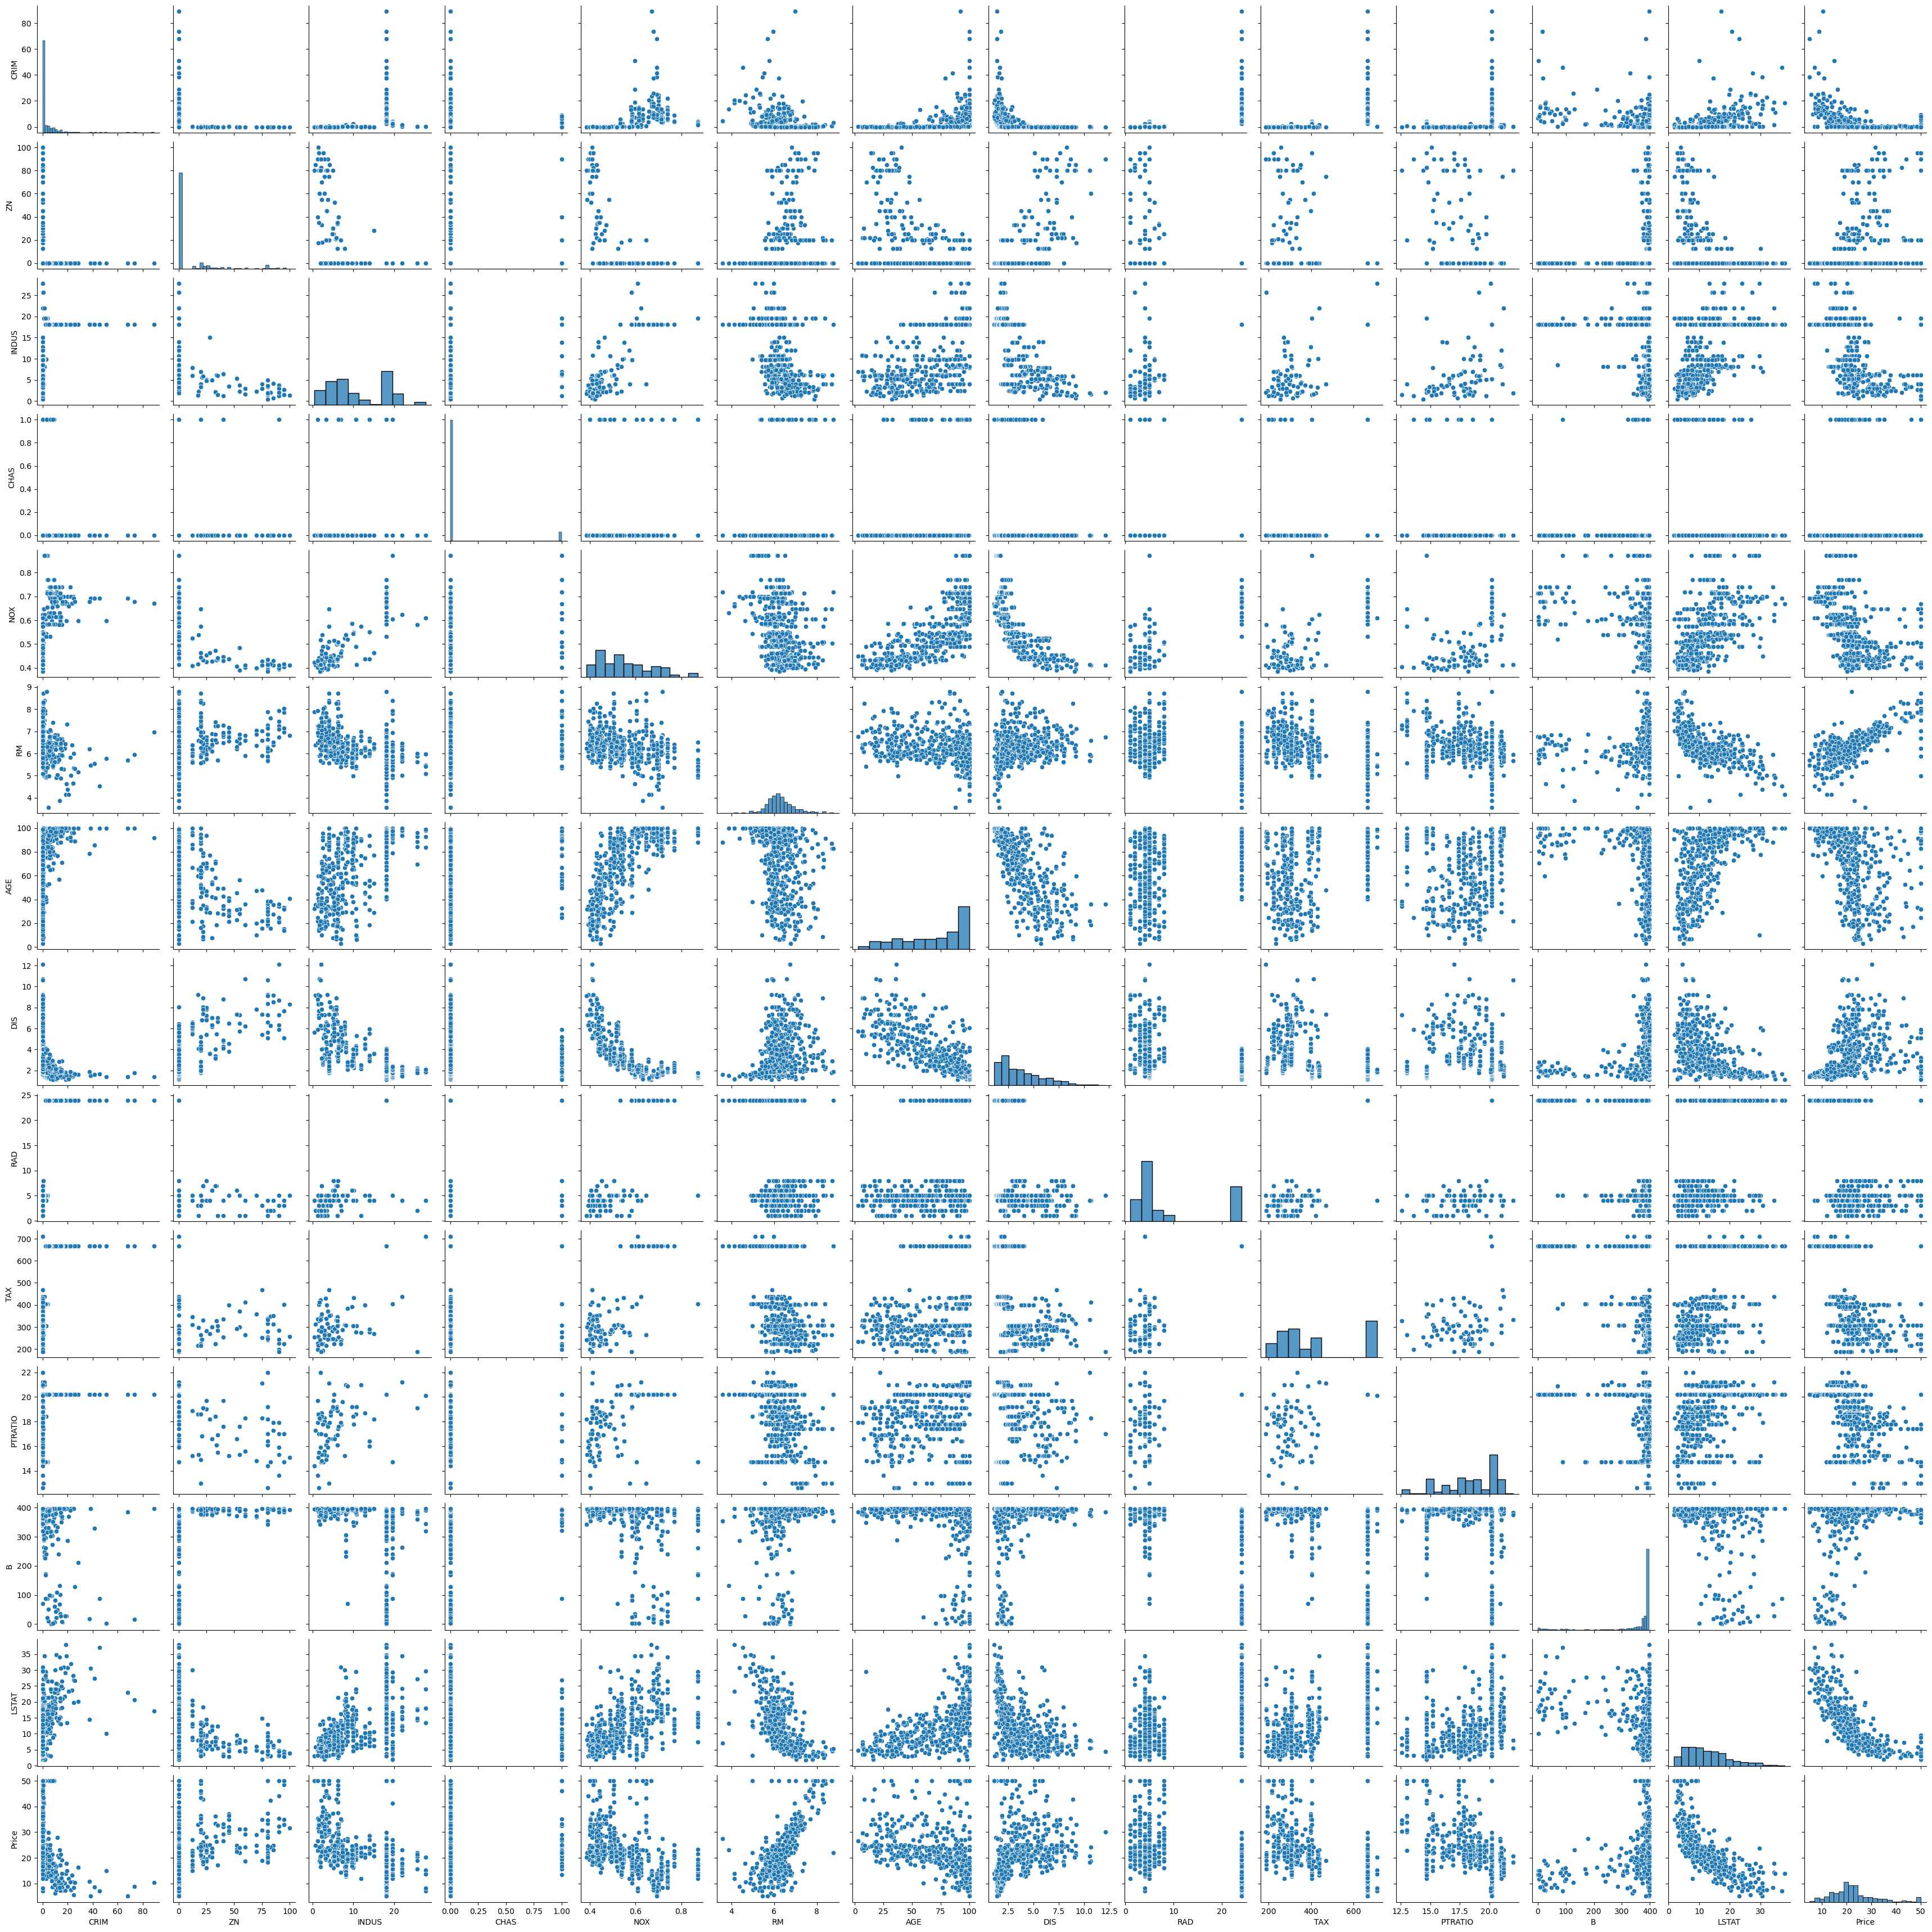

In [152]:
import seaborn as sns
sns.pairplot(boston_df)

Analyzing Correlated Features

Text(0, 0.5, 'Price')

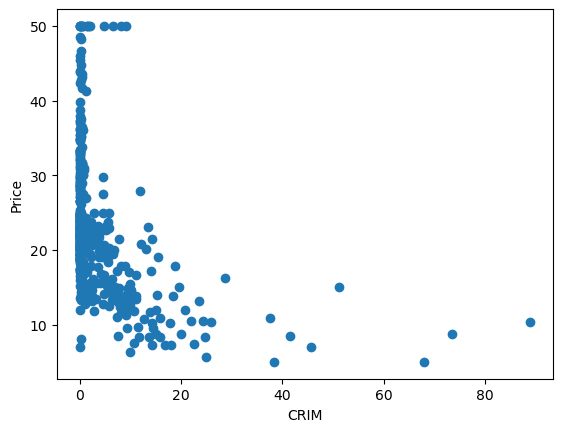

In [153]:
plt.scatter(boston_df['CRIM'], boston_df['Price'])
plt.xlabel('CRIM')
plt.ylabel('Price')

<Axes: xlabel='CRIM', ylabel='Price'>

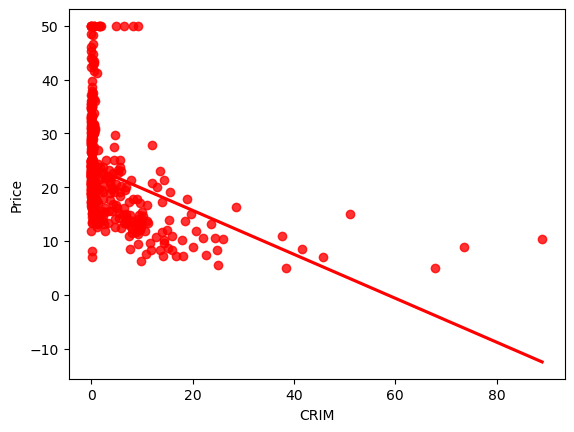

In [154]:
sns.regplot(x=boston_df['CRIM'], y=boston_df['Price'], ci=None, color ='red')

Independent and Depenent Features

In [155]:
x = boston_df.iloc[:, :-1]   # ALL rows, ALL columns EXCEPT the last
y = boston_df.iloc[:, -1]    # ALL rows, ONLY the last column

In [156]:
x.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN


In [157]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: Price, Length: 506, dtype: float64

Train Test Split

In [158]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

Standardization


In [159]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [160]:
x_train = scaler.fit_transform(x_train) #Learns mean & std from training data, then scales it
x_test = scaler.transform(x_test) #Uses the already learned mean & std to scale test data

In [161]:
import pickle
pickle.dump(scaler, open('scaling.pkl', 'wb'))

In [165]:
x_train

array([[-0.40910878, -0.50110191, -1.28500964, ...,  0.18727079,
         0.39651419, -1.02369482],
       [-0.39706871, -0.50110191, -0.1500398 , ..., -0.21208981,
         0.3870674 ,         nan],
       [-0.39235352, -0.50110191, -0.59938929, ..., -0.16771641,
         0.42854113, -0.3182736 ],
       ...,
       [-0.41086514,  3.000543  , -1.30965138, ..., -0.56707702,
         0.35987906, -0.91364911],
       [ 0.90822698, -0.50110191,  1.02261741, ...,  0.8528718 ,
        -2.87841346,  1.52428661],
       [-0.38556715, -0.50110191, -0.3602194 , ...,  1.16348561,
        -3.32828832, -0.25901822]], shape=(354, 13))

In [166]:
x_test

array([[-0.40177917, -0.50110191,         nan, ..., -0.74457062,
         0.41241246, -0.48334217],
       [-0.40596177,  1.24972054, -0.67186501, ..., -0.30083661,
         0.42854113, -1.26071635],
       [-0.40012696, -0.50110191,  2.41994936, ...,  0.8084984 ,
         0.35031705,  0.79064855],
       ...,
       [-0.35027779, -0.50110191, -0.70230482, ..., -0.38958342,
         0.25688594, -1.10552368],
       [ 0.24789564, -0.50110191,  1.02261741, ...,  0.8528718 ,
        -2.98970133,  0.5296427 ],
       [ 0.76199573, -0.50110191,  1.02261741, ...,  0.8528718 ,
         0.33199949,  0.56068123]], shape=(152, 13))

Standardizing data ensures that gradient descent converges faster, avoids extreme oscillations, and handles all features with equal importance during optimization

**MODEL TRAINING**

In [167]:
from sklearn.linear_model import LinearRegression

In [168]:
regression =  LinearRegression()

In [169]:
print(boston_df.isnull().sum()) # Check for missing values in the dataset

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
Price       0
dtype: int64


In [170]:
print(boston_df.isnull().any())   # which columns have NaNs

CRIM        True
ZN          True
INDUS       True
CHAS        True
NOX        False
RM         False
AGE         True
DIS        False
RAD        False
TAX        False
PTRATIO    False
B          False
LSTAT       True
Price      False
dtype: bool


In [171]:
from sklearn.impute import SimpleImputer # filling with mean

imputer = SimpleImputer(strategy='mean')
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [172]:
regression.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [173]:
#Print the coefficients
print(regression.coef_)

[-1.08812808  0.73307619 -0.0706001   0.96367861 -1.62710196  3.16908177
 -0.70992229 -3.04173421  1.69971542 -1.2041203  -1.99730105  1.01939871
 -3.36159215]


In [174]:
print(regression.intercept_) #prints the bias term (β₀) of the fitted linear regression model.

23.01581920903955


In [175]:
#Training Parameters
regression.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [176]:
print(scaler.n_features_in_)  # Should print 13
print(boston_df.shape)    # Check how many features you're passing
print(boston_df.columns.tolist())  # List the feature names

13
(506, 14)
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'Price']


Prediction with test data

In [99]:
reg_pred = regression.predict(x_test) #This code uses the trained model to predict house prices on the test data.

In [100]:
reg_pred

array([28.9374149 , 37.07304671, 15.15824707, 25.59079669, 18.51249014,
       22.9224732 , 17.98048338, 14.42684379, 22.06118216, 20.81179321,
       25.10710077, 18.7280536 , -6.31900083, 21.85652534, 19.0211192 ,
       25.51260116, 19.37792708,  5.95171499, 40.85420827, 17.17691806,
       25.03739352, 30.36508097, 11.38739503, 22.87828871, 17.50615507,
       15.11529181, 21.50352281, 14.47474002, 23.13096798, 19.55796172,
       22.17502166, 25.2549366 , 25.38313785, 17.34560951, 16.23169931,
       17.26234025, 30.90624604, 20.38720519, 24.66260953, 22.95762537,
       14.50885487, 31.79168268, 42.81647959, 17.98159357, 27.35228492,
       16.55933678, 13.94631048, 26.52214645, 19.74265463, 30.25608467,
       21.0220061 , 33.47226081, 15.9679993 , 26.26674791, 39.5833181 ,
       22.49822654, 18.74466842, 33.03174115, 25.24212083, 13.17269654,
       22.8454891 , 31.01734562, 31.54634839, 16.75114519, 21.21601556,
       17.09250986, 19.98323684, 26.38211499, 31.29810985, 11.72

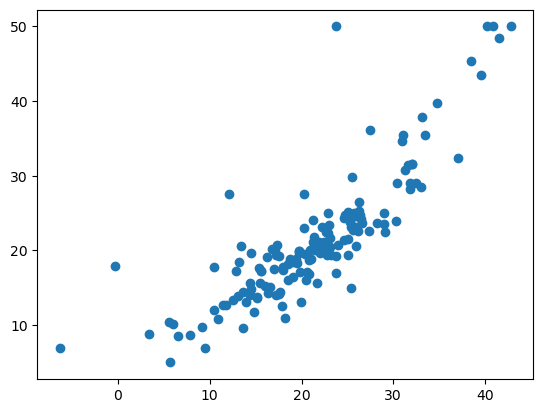

In [101]:
plt.scatter(reg_pred, y_test)


In [38]:
#Prediction with Residuals
residuals = y_test - reg_pred

In [39]:
residuals

173   -5.337415
274   -4.673047
491   -1.558247
72    -2.790797
452   -2.412490
         ...   
441   -3.502792
23     0.915006
225    9.786582
433   -2.091002
447   -5.263441
Name: target, Length: 152, dtype: float64

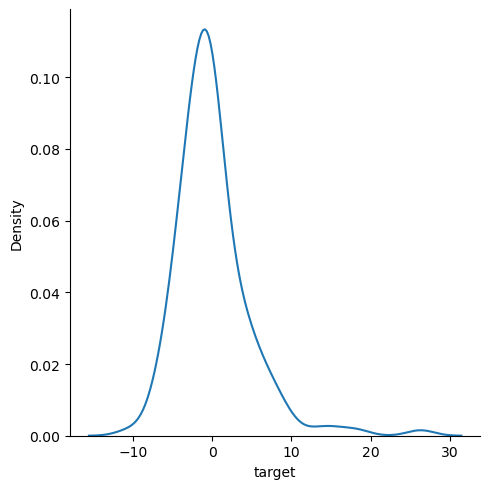

In [40]:
#Plot thr Residuals

sns.displot(residuals, kind='kde') #KDE (Kernel Density Estimate) of the residuals to check if errors are normally distributed.

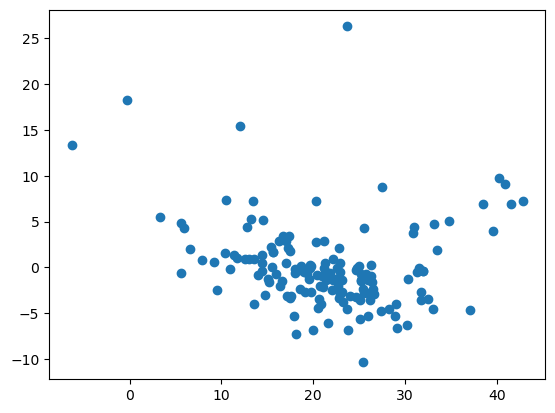

In [41]:
plt.scatter(reg_pred,residuals)

In [42]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test, reg_pred))
print(mean_squared_error(y_test, reg_pred))
print(np.sqrt(mean_squared_error(y_test, reg_pred)))

# mean_squared_error(y_test, reg_pred)
# → calculates the average of squared differences
#   between actual (y_test) and predicted (reg_pred) values
#   Formula: MSE = mean((y_actual - y_predicted)²)

# np.sqrt(...)
# → takes the square root of MSE
#   this gives us RMSE (Root Mean Squared Error)
#   Formula: RMSE = √MSE

# Why square root?
# → MSE is in squared units ($1000s²) which is hard to interpret
# → RMSE brings it back to original units ($1000s)
# → So RMSE tells us: on average, predictions are off by $X,000

3.139950354468795
21.814655758667044
4.670616207596921


Adjusted and R Squared

In [43]:
from sklearn.metrics import r2_score
score = r2_score(y_test, reg_pred)
print(score)

0.7072372904062467


In [44]:
#Adusted R2
1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)

0.6796581945749511

New Data Prediction

In [45]:
boston_df


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,target
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [46]:
boston_df.shape


(506, 14)

In [47]:
boston_df.iloc[0]

CRIM         0.00632
ZN          18.00000
INDUS        2.31000
CHAS         0.00000
NOX          0.53800
RM           6.57500
AGE         65.20000
DIS          4.09000
RAD          1.00000
TAX        296.00000
PTRATIO     15.30000
B          396.90000
LSTAT        4.98000
target      24.00000
Name: 0, dtype: float64

In [48]:
boston_df.iloc[0]           # first row as pandas Series
boston_df.iloc[0].values.reshape(1, -1)   # convert to numpy array → shape (13,)
                              # reshape to (1, 13) — 1 row, 13 columns

array([[6.320e-03, 1.800e+01, 2.310e+00, 0.000e+00, 5.380e-01, 6.575e+00,
        6.520e+01, 4.090e+00, 1.000e+00, 2.960e+02, 1.530e+01, 3.969e+02,
        4.980e+00, 2.400e+01]])

In [49]:
#  Use x (features only) instead of boston_df (all columns)
scaler.transform(x.iloc[0].values.reshape(1, -1))

c:\6 SEM\ML PROJECTS\House Prediction\House-Prediction-Project-Linear-Regression\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-0.41189363,  0.28676819, -1.26616595, -0.28261671, -0.16513629,
         0.34715902, -0.12971024,  0.15267164, -0.97798895, -0.66777595,
        -1.32142483,  0.42854113, -1.0561442 ]])

In [50]:
regression.predict(scaler.transform(x.iloc[0].values.reshape(1, -1)))

c:\6 SEM\ML PROJECTS\House Prediction\House-Prediction-Project-Linear-Regression\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([30.25608467])

Picking the model file for DEPLOYMENT

In [ ]:
import pickle


In [ ]:
pickle.dump(regression,open('regmodel.pkl','wb'))

In [ ]:
from google.colab import files

files.download('regmodel.pkl')

print("Model saved!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved!


In [ ]:
pickled_model = pickle.load(open('regmodel.pkl','rb'))

In [ ]:
pickled_model.predict(scaler.transform(x.iloc[0].values.reshape(1, -1)))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([30.25608467])